In [1]:
!pip install transformers==4.28.0
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 20.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.20.0
    Uninstalling transformers-4.20.0:
      Successfully uninstalled transformers-4.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 17.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.20.3
    Uninstalling huggingface-hub-0.20.3:
      Successfully uninstalled huggingface-hub-0.20.3


In [2]:
import re
import string
import tensorflow as tf

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer
from transformers import AdamW, get_linear_schedule_with_warmup, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
train = pd.read_csv("/content/train_dataset.csv")
validation = pd.read_csv("/content/validation_dataset.csv")
test = pd.read_csv("/content/test_dataset.csv")

In [5]:
import datasets
import pandas as pd
from datasets import Dataset, DatasetDict

train_df = pd.DataFrame({
     "text" : train["Translated_Text"],
     "labels" : train['label']

})
val_df = pd.DataFrame({
     "text" : validation["Translated_Text"],
     "labels" : validation['label']

})

test_df = pd.DataFrame({
     "text" : test["Translated_Text"],
     "labels" : test['label']

})

train_dataset = Dataset.from_dict(train_df)
val_dataset = Dataset.from_dict(val_df)
test_dataset = Dataset.from_dict(test_df)
dataset = datasets.DatasetDict({"train":train_dataset,"validation":val_dataset,"test":test_dataset})

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 862
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 96
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 240
    })
})

In [7]:
dataset.num_rows

{'train': 862, 'validation': 96, 'test': 240}

In [8]:
dataset['train'][0]

{'text': 'το μεγαλύτερο σημάδι του ουαλί του αλλάχ είναι ότι έχει επίγνωση του παρόντος ούτε μετανιώνει για το παρελθόν ούτε φοβάται το μέλλον',
 'labels': 0}

In [9]:
train.head()

,Tweets,label,Translated_Text
0,the greatest sign of the wali of allah is that...,0,το μεγαλύτερο σημάδι του ουαλί του αλλάχ είναι...
1,the oneyearold boy who was tortured so much by...,0,το ενός έτους αγόρι που βασανίστηκε τόσο πολύ ...
2,every person who pays for the pashtun tahafuz ...,0,κάθε άτομο που πληρώνει για το κίνημα των παστ...
3,gee you have found a good similarity but the r...,0,γκι έχετε βρει μια καλή ομοιότητα αλλά ο πραγμ...
4,ahsan iqbal is giving bashan like nawaz sharif...,0,ο άχσαν ικμπάλ δίνει μπάσαν όπως ο ναουάζ σαρί...


In [10]:
test.head()

,Tweets,label,Translated_Text
0,neither agreed in any matter nor united in any...,0,ούτε σύμφωνοι σε κανένα θέμα ούτε ενωμένοι σε ...
1,oh they are sick and silent without honor ask ...,0,ω είναι άρρωστοι και σιωπηλοί χωρίς τιμή ρωτήσ...
2,stop the nonsense you pigs,1,σταματήστε τις ανοησίες γουρούνια
3,vote for me before the election i will hang th...,1,ψηφίστε με πριν τις εκλογές θα κρεμάσω τους κλ...
4,where will they have so much courage to break ...,1,πού θα έχουν τόσο κουράγιο να σπάσουν τα πόδια...


In [11]:
validation.head()

,Tweets,label,Translated_Text
0,thieves miscreants escaped from the court this...,1,οι κλέφτες οι παραβάτες διέφυγαν από το δικαστ...
1,modi should remember that millions of young pe...,1,ο μόντι πρέπει να θυμάται ότι εκατομμύρια νέοι...
2,you are the dogs tail that was tied for twelve...,0,είσαι η ουρά του σκύλου που ήταν δεμένη για δώ...
3,i drink a lot of tea cigarettes and tears of b...,0,πίνω πολύ τσάι τσιγάρα και δάκρυα από αίμα
4,there is some hope now,0,υπάρχει κάποια ελπίδα τώρα


#Hyperparameters

In [12]:
num_epoch = 10
sq_len = 128
batch_size = 32
lr_rate = 2e-5
epsilon = 1e-8
hidden_dropout = 0.05
warmup_ratio = 0.06
weight_decay = 0.01

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('setu4993/LaBSE')

def encode_batch(batch):
  """Encodes a batch of input data using the model tokenizer."""
  return tokenizer(batch["text"], max_length=sq_len, truncation=True, padding="max_length")

# Encode the input data
dataset = dataset.map(encode_batch, batched=True)
# The transformers model expects the target class column to be named "labels"
#dataset.rename_column_("label", "labels")
# Transform to pytorch tensors and only output the required columns
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/5.22M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/862 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

In [14]:
# Calculation of the maximum length of any text in terms of tokens

max_len = 0

# Concatenate all datasets
all_texts_df = pd.concat([train["Translated_Text"], validation["Translated_Text"], test["Translated_Text"]])

# Iterate through each text in the dataset
for text in all_texts_df:
    input_ids = tokenizer.encode(text, add_special_tokens=True)
    max_len = max(max_len, len(input_ids))

print(f"The maximum length of any text in terms of tokens is: {max_len}")


The maximum length of any text in terms of tokens is: 110


In [15]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 862
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 96
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 240
    })
})

## Training

In [16]:
from transformers import AutoConfig, AutoModelForSequenceClassification

# Model and training configuration
config = AutoConfig.from_pretrained('setu4993/LaBSE',
                                    num_labels=2,
                                    problem_type="single_label_classification")

config.hidden_dropout_prob = hidden_dropout
model = AutoModelForSequenceClassification.from_pretrained('setu4993/LaBSE', config=config)

config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at setu4993/LaBSE and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [18]:
# Define the function to compute the metrics during evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,precision_score,recall_score,confusion_matrix
import time
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    precision = precision_score(labels, preds, average='weighted',zero_division=0)
    recall = recall_score(labels, preds, average='weighted',zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}



In [19]:
optimizer = AdamW(model.parameters(), lr=lr_rate, eps=epsilon)
total_steps = len(dataset["train"]) * num_epoch
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [20]:
from datetime import datetime
import pandas as pd

# Create empty lists to store results
epoch_list = []
training_loss_list = []
validation_loss_list = []
training_time_list = []
validation_time_list = []
validation_accuracy_list = []
validation_f1_list = []

test_tp_list = []
test_tn_list = []
test_fp_list = []
test_fn_list = []

test_accuracy_list = []
test_f1_list = []
test_precision_list = []
test_recall_list = []
# Define the trainer Arguments
training_args = TrainingArguments(
          output_dir='./results',
          overwrite_output_dir='True',
          num_train_epochs=1,
          per_device_train_batch_size=batch_size,
          per_device_eval_batch_size=batch_size,
          warmup_ratio=warmup_ratio,
          weight_decay=weight_decay,
          logging_dir='./logs',
          logging_steps=100,
          save_strategy='no',
          evaluation_strategy='no',
          load_best_model_at_end=True,
          metric_for_best_model='accuracy',
          greater_is_better=True,


    )

train_epoch = num_epoch
# Train the model and track the metrics after each epoch
for epoch in range(train_epoch):


    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        # optimizers=(optimizer, None)
    )


    # Train the model for one epoch
    start_time = datetime.now()
    train_result = trainer.train()
    end_time = datetime.now()

    # Perform optimization steps
    optimizer.step()


    # Clear gradients
    optimizer.zero_grad()

    # Perform evaluation on the validation set
    validation_result = trainer.evaluate(eval_dataset=dataset["validation"])

    # Perform evaluation on the test set
    test_result = trainer.evaluate(eval_dataset=dataset["test"])


    # Extract the desired information
    training_loss = train_result.training_loss
    validation_loss = validation_result["eval_loss"]

    validation_time = validation_result["eval_runtime"]
    training_time = train_result.metrics["train_runtime"]

    validation_accuracy = validation_result["eval_accuracy"]
    validation_f1 = validation_result["eval_f1"]


    test_accuracy = test_result["eval_accuracy"]
    test_f1 = test_result["eval_f1"]
    test_precision = test_result["eval_precision"]
    test_recall = test_result["eval_recall"]

    test_tp = test_result["eval_tp"]
    test_tn = test_result["eval_tn"]
    test_fp = test_result["eval_fp"]
    test_fn = test_result["eval_fn"]

    val_runtime_formatted = pd.to_datetime(validation_time, unit='s').strftime('%H:%M:%S')
    train_runtime_formatted = pd.to_datetime(training_time, unit='s').strftime('%H:%M:%S')

    # Append the metrics to the respective lists
    epoch_list.append(epoch + 1)
    training_loss_list.append(training_loss)
    validation_loss_list.append(validation_loss)

    validation_accuracy_list.append(validation_accuracy)
    validation_f1_list.append(validation_f1)

    training_time_list.append(train_runtime_formatted)
    validation_time_list.append(val_runtime_formatted)

    test_tp_list.append(test_tp)
    test_tn_list.append(test_tn)
    test_fp_list.append(test_fp)
    test_fn_list.append(test_fn)


    test_accuracy_list.append(test_accuracy)
    test_f1_list.append(test_f1)
    test_precision_list.append(test_precision)
    test_recall_list.append(test_recall)

# Create a DataFrame to store the results
train_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Training Loss": training_loss_list,
    "Validation Loss": validation_loss_list,
    "Validation Accuracy": validation_accuracy_list,
    "Validation F1": validation_f1_list,
    "Training Time": training_time_list,
    "Validation Time": validation_time_list,
})

test_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Test TP": test_tp_list,
    "Test TN": test_tn_list,
    "Test FP": test_fp_list,
    "Test FN": test_fn_list,
    "Test Accuracy": test_accuracy_list,
    "Test F1": test_f1_list,
    "Test Precision": test_precision_list,
    "Test Recall": test_recall_list,
})

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


In [21]:
train_df.head(10)

,Epoch,Training Loss,Validation Loss,Validation Accuracy,Validation F1,Training Time,Validation Time
0,1,0.554435,0.421603,0.822917,0.822744,00:00:08,00:00:00
1,2,0.337243,0.429428,0.864583,0.864215,00:00:06,00:00:00
2,3,0.241116,0.660919,0.802083,0.801890,00:00:06,00:00:00
3,4,0.296653,1.039893,0.812500,0.812174,00:00:06,00:00:00
4,5,0.328198,1.162759,0.822917,0.821346,00:00:06,00:00:00
5,6,0.244005,1.475154,0.791667,0.785714,00:00:06,00:00:00
6,7,0.207261,1.276948,0.822917,0.821970,00:00:06,00:00:00
7,8,0.158435,1.428560,0.833333,0.832680,00:00:06,00:00:00
8,9,0.228319,1.654674,0.802083,0.801890,00:00:06,00:00:00
9,10,0.145023,1.662717,0.812500,0.812419,00:00:06,00:00:00


In [22]:
test_df.head(10)

,Epoch,Test TP,Test TN,Test FP,Test FN,Test Accuracy,Test F1,Test Precision,Test Recall
0,1,106,99,21,14,0.854167,0.854043,0.855376,0.854167
1,2,106,105,15,14,0.879167,0.879165,0.879193,0.879167
2,3,108,99,21,12,0.862500,0.862306,0.864551,0.862500
3,4,105,100,20,15,0.854167,0.854103,0.854783,0.854167
4,5,81,111,9,39,0.800000,0.796825,0.820000,0.800000
5,6,88,107,13,32,0.812500,0.811317,0.820536,0.812500
6,7,102,104,16,18,0.858333,0.858323,0.858433,0.858333
7,8,96,103,17,24,0.829167,0.829021,0.830291,0.829167
8,9,110,98,22,10,0.866667,0.866332,0.870370,0.866667
9,10,101,102,18,19,0.845833,0.845831,0.845857,0.845833


#Store Results in Excel File

In [23]:
train_df.to_excel("Train LaBSE-128SL-32BS-0.05HD-0.06WR-0.01WD.xlsx")

In [24]:
test_df.to_excel("Test LaBSE-128SL-32BS-0.05HD-0.06WR-0.01WD.xlsx")

# Attention Visualization

In [25]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

# Load again the model and tokenizer with attention output enabled
tokenizer = AutoTokenizer.from_pretrained('setu4993/LaBSE')
model = AutoModelForSequenceClassification.from_pretrained('setu4993/LaBSE', output_attentions=True)

# Evaluation mode
model.eval()

# Sample sentence
sentence = "αυτοί που πληρώνουν τους φόρους μας συνεχίζουν να μας δείχνουν τα μάτια βγάλτε τους τα μάτια πάρτε τα και πετάξτε τα έξω από τα ίδια ιδρύματα" # Hate speech sentence from train dataset
inputs = tokenizer(sentence, return_tensors='pt', padding=True, truncation=True, max_length=128)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at setu4993/LaBSE and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:

# Transfer inputs to the same device of the model
device = next(model.parameters()).device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions

# Flatten the attentions
attention = torch.cat([att for layer in attentions for att in layer], dim=0)
attention = attention.mean(dim=0)

In [27]:
# Convert attention matrix to numpy
attention_matrix = attention.cpu().numpy()

# Convert input IDs to tokens for labeling axes
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'].squeeze().tolist())

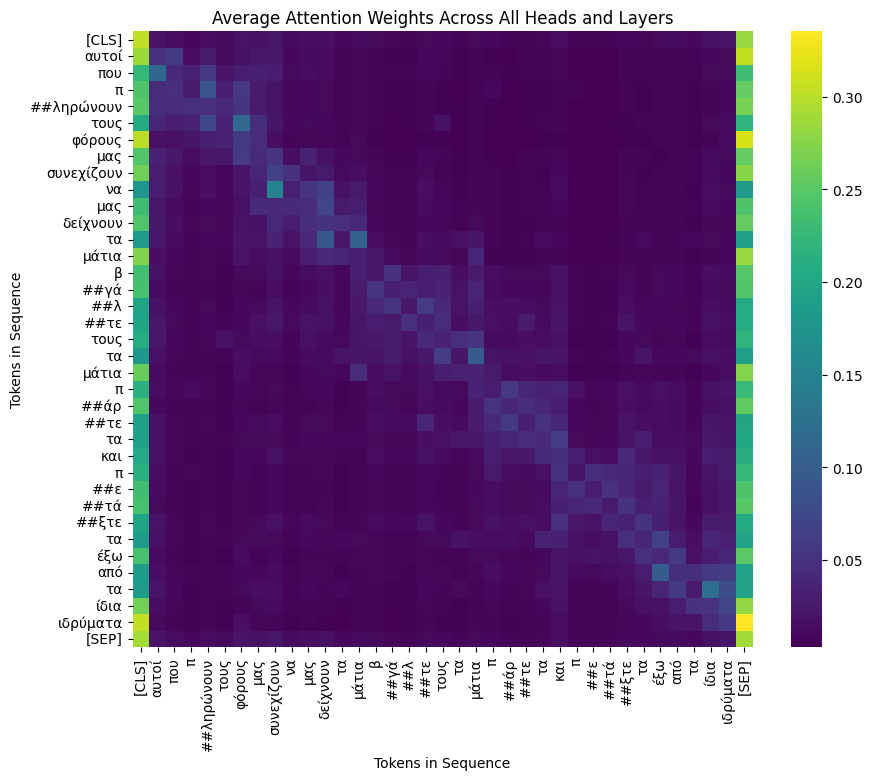

In [28]:
# Visualization of attention weights
plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title('Average Attention Weights Across All Heads and Layers')
plt.xlabel('Tokens in Sequence')
plt.ylabel('Tokens in Sequence')
plt.show()

For example, ##τα most likely stands for either a suffix or a part of some bigger word which has been split by the tokenizer for better comprehension. The bright spots such as that linking ##φορούς with ##μας represent regions where attention concentrates. This is what the sentence means in terms of hate speech as perceived by the model.

#Counterfactual Explanations

In [29]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import shap
import scipy as sp

# Load again tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('setu4993/LaBSE')
model = AutoModelForSequenceClassification.from_pretrained('setu4993/LaBSE')
model.eval()

# Check the availability of CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(all_masks, max_swap_size=100, num_

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(501153, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [148]:
# Prediction function
def f(x):
    tv = torch.tensor(
        [
            tokenizer.encode(v, padding="max_length", max_length=128, truncation=True)
            for v in x
        ]
    ).cuda()
    outputs = model(tv)[0].detach().cpu().numpy()
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    return sp.special.logit(scores[:, 1])

# Πrediction function for pre-encoded inputs
def predict(inputs):
    inputs = {key: value.to(device) for key, value in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = F.softmax(outputs.logits, dim=-1)
        predictions = torch.argmax(probabilities, dim=-1)
    return probabilities, predictions

# Example sentences for prediction
text = "σταματήστε τις ανοησίες σήμερα ο λαός της ινδίας υποφέρει από αυτό το σκυλί οι μουσουλμάνοι του πακιστάν και ο λαός της ινδίας αντιμετωπίζουν προβλήματα εξαιτίας αυτού του ανθρώπου"  # original hate speech sentence from train dataset
counterfactual_text = "ας εστιάσουμε στα σημαντικά θέματα σήμερα οι κοινότητες τόσο στην ινδία όσο και στο πακιστάν αντιμετωπίζουν σοβαρές προκλήσεις οι οποίες χρήζουν της κοινής μας προσοχής και κατανόησης"  # it's similar to the original one but without hate speech


In [149]:
# SHAP explainer initialization
explainer = shap.Explainer(f, tokenizer)

# Calculate SHAP values
shap_values = explainer([text, counterfactual_text])

# Visualize the explanation for both texts
shap.plots.text(shap_values[0])
shap.plots.text(shap_values[1])

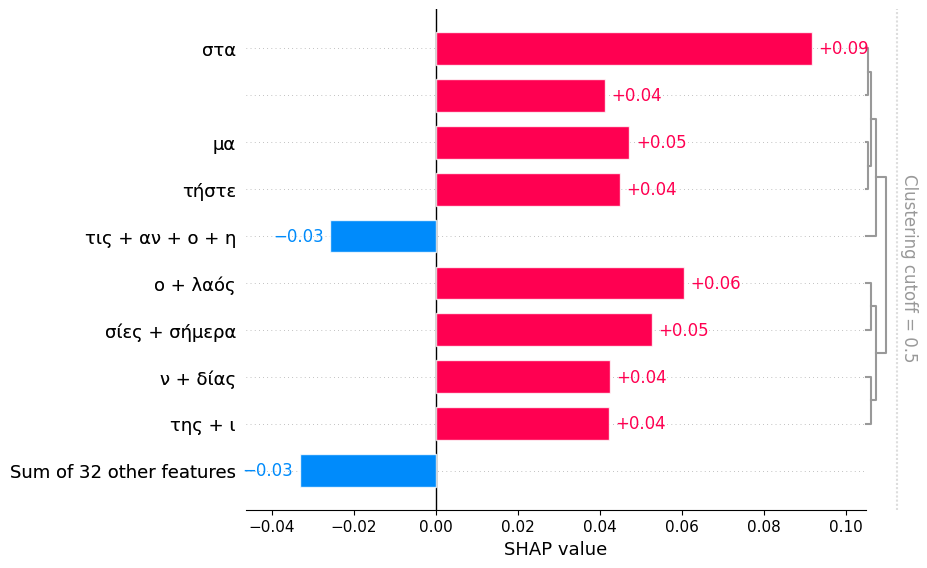

In [150]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0

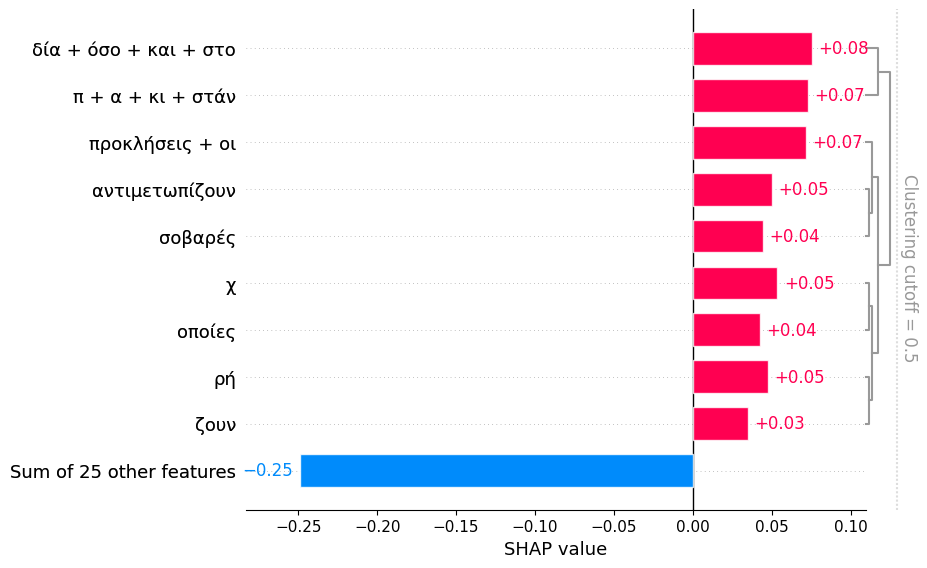

In [151]:
# Bar plot of Shap values
shap.plots.bar(shap_values[1]) # for instance 1

In [152]:
# Encode both the original and counterfactual texts
encoded_input = tokenizer(text, return_tensors='pt', max_length=512, truncation=True, padding='max_length').to(device)
encoded_counterfactual = tokenizer(counterfactual_text, return_tensors='pt', max_length=512, truncation=True, padding='max_length').to(device)

# Predictions and probabilities for the original and counterfactual texts
original_probabilities, original_predictions = predict(encoded_input)
counterfactual_probabilities, counterfactual_predictions = predict(encoded_counterfactual)


In [153]:
# Prepare data for saving
data = {
    "Text": ["Original text", "Counterfactual text"],
    "Probabilities": [original_probabilities.tolist(), counterfactual_probabilities.tolist()],
    "Predicted Class": [original_predictions.item(), counterfactual_predictions.item()]
}

# Creation of a DataFrame
results_df = pd.DataFrame(data)

# Save to a CSV file
results_df.to_csv('model_predictions.csv', index=False)
